## 音频数据的特征工程

### 1.二阶谱提取

In [ ]:
import import_ipynb
from MyPreprocess import *
from Extract_bispectrum import polycoherence,plot_polycoherence

ex_audio_data = down_sample_audio_data[:3000]
freq1, freq2, bi_spectrum = polycoherence(ex_audio_data, nfft=1024, nperseg=256, noverlap = 128, fs = 2000, norm=None)
bi_spectrum = np.array(abs(bi_spectrum))  # calculate bi_spectrum
bi_spectrum = 255 * (bi_spectrum - np.min(bi_spectrum)) / (np.max(bi_spectrum) - np.min(bi_spectrum))
# plot_polycoherence(freq1, freq2, bi_spectrum) 可视化二阶谱
bi_spectrum = bi_spectrum.reshape((256, 256, 1))



### 2.MFCC

In [2]:
import librosa
from python_speech_features import mfcc

# 基本的提取MFCC特征
def getMFCC0(y, sr):
    mfcc0 = mfcc(y, sr, numcep=13)
    return mfcc0

# 计算一阶和二阶差分并合并
def getMFCCMap(y, sr=2000):
    mfcc0 = mfcc(y, sr, numcep=13)
    mf1 = librosa.feature.delta(mfcc0)
    mf2 = librosa.feature.delta(mfcc0, order=2)
    mfcc_all=np.hstack((mfcc0,mf1,mf2))
    mfcc_all1=mfcc_all.reshape(499,39,1)
    return mfcc_all1


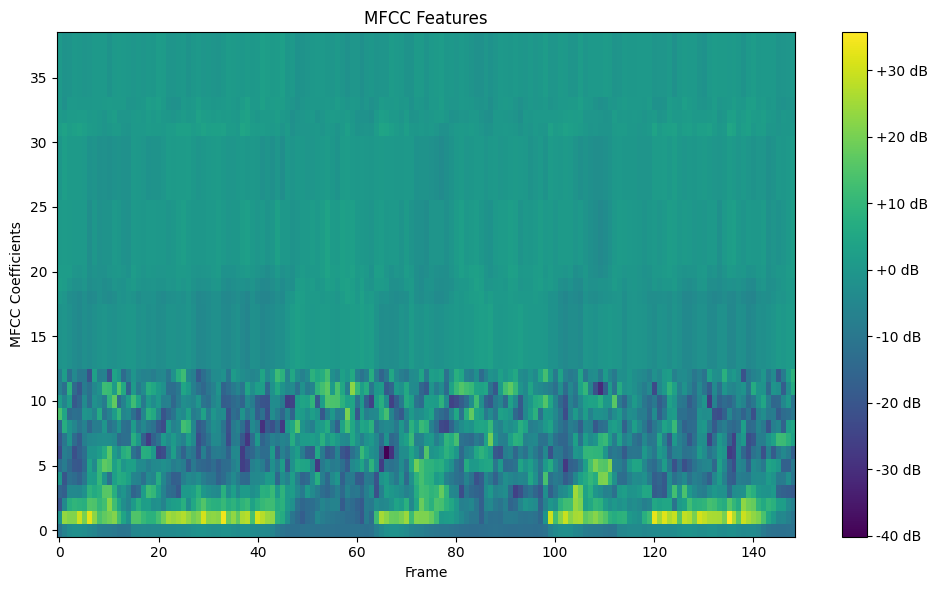

In [ ]:
import librosa
import numpy as np
import matplotlib.pyplot as plt
from python_speech_features import mfcc

# 基本的提取MFCC特征
def getMFCC0(y, sr):
    mfcc0 = mfcc(y, sr, numcep=13)
    return mfcc0

# 计算一阶和二阶差分并合并
def getMFCCMap(y, sr=2000):
    mfcc0 = mfcc(y, sr, numcep=13)
    mf1 = librosa.feature.delta(mfcc0)
    mf2 = librosa.feature.delta(mfcc0, order=2)
    mfcc_all = np.hstack((mfcc0, mf1, mf2))
    mfcc_all1 = mfcc_all.reshape(-1, 39)  
    return mfcc_all1

# 读取音频文件
def read_audio(file_path, sr=2000):
    y, sr = librosa.load(file_path, sr=sr)
    return y, sr

# 可视化MFCC特征
def plot_mfcc(mfcc_features):
    plt.figure(figsize=(10, 6))
    plt.imshow(mfcc_features.T, cmap='viridis', origin='lower', aspect='auto')
    plt.colorbar(format='%+2.0f dB')
    plt.title('MFCC Features')
    plt.xlabel('Frame')
    plt.ylabel('MFCC Coefficients')
    plt.tight_layout()
    plt.show()

# 主函数
if __name__ == "__main__":
    # 替换路径
    audio_path = '../HeartSound1/datasets/five_class/MS/New_MS_001.wav'
    y, sr = read_audio(audio_path)

    mfcc_features = getMFCCMap(y, sr)
    
    if mfcc_features.shape[0] > 149:
        mfcc_features = mfcc_features[:149, :]
    elif mfcc_features.shape[0] < 149:
        padding = np.zeros((149 - mfcc_features.shape[0], 39))
        mfcc_features = np.vstack((mfcc_features, padding))
    
    # 可视化MFCC特征
    plot_mfcc(mfcc_features)